# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [13]:
class HumanPlayer(Player):
    def make_decision(self, running_count, dealer_card):
        print(f"\nYour hand: {[c.rank for c in self.hand]} (Score: {self.get_score()})")
        print(f"Dealer showing: {dealer_card.rank}")
        choice = input("Hit or stay? ").lower()
        return "hit" if choice == "hit" else "stay"

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

In [14]:
class Dealer(Player):
    def make_decision(self, running_count=None, dealer_card=None):
        return "hit" if self.get_score() < 17 else "stay"

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [15]:
class SimpleCountingPlayer(Player):
    def __init__(self, name, chips=1000, threshold=0):
        super().__init__(name, chips)
        self.threshold = threshold

    def make_decision(self, running_count, dealer_card):
        score = self.get_score()
        if score >= 21:
            return "stay"
        if running_count < self.threshold:
            return "hit"
        else:
            return "stay" if score >= 12 else "hit"

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [16]:
def play_round(self):
    if self.deck.needs_shuffle:
        self.deck.reset()
        self.running_count = 0

    all_active = [p for p in self.players if p.chips >= p.current_bet]
    for p in all_active + [self.dealer]:
        p.hand = []
    for _ in range(2):
        for p in all_active + [self.dealer]:
            card = self.deck.draw()
            p.hand.append(card)
            if not (p == self.dealer and len(p.hand) == 2):
                self.update_count(card)
    if self.verbose:
        print("\n--- New Round ---")

    for p in all_active:
        while p.get_score() < 21:
            action = p.make_decision(self.running_count, self.dealer.hand[0])
            if action == "hit":
                card = self.deck.draw()
                p.hand.append(card)
                self.update_count(card)
            else:
                break
    self.update_count(self.dealer.hand[1])
    while self.dealer.get_score() < 17:
        card = self.deck.draw()
        self.dealer.hand.append(card)
        self.update_count(card)

    d_score = self.dealer.get_score()
    for p in all_active:
        p_score = p.get_score()

        if p_score > 21:
            p.chips -= p.current_bet
        elif d_score > 21 or p_score > d_score:
            p.chips += p.current_bet
        elif p_score < d_score:
            p.chips -= p.current_bet

        if self.verbose:
            print(f"{p.name}: {p_score}, Chips: {p.chips}")

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [17]:
def test_strategy(threshold):
    strategy_player = SimpleCountingPlayer("Strategy", 1000, threshold)
    others = [Player(f"P{i}") for i in range(3)]

    game = BlackjackGame([strategy_player] + others)

    for _ in range(50):
        game.play_round()
        if strategy_player.chips <= 0:
            break

    return strategy_player.chips

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [19]:
def run_experiment(threshold):
    results = []
    for _ in range(100):
        chips = test_strategy(threshold)
        results.append(chips - 1000)

    results = np.array(results)

    print(f"\nThreshold {threshold}")
    print(f"Average: {np.mean(results)}")
    print(f"Std Dev: {np.std(results)}")
    print(f"Prob Profit: {np.mean(results > 0)}")
    plt.hist(results, bins=20, edgecolor='black')
    plt.title(f"Threshold {threshold}")
    plt.show()

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.


Threshold -4
Average: -115.0
Std Dev: 74.34379597518544
Prob Profit: 0.05


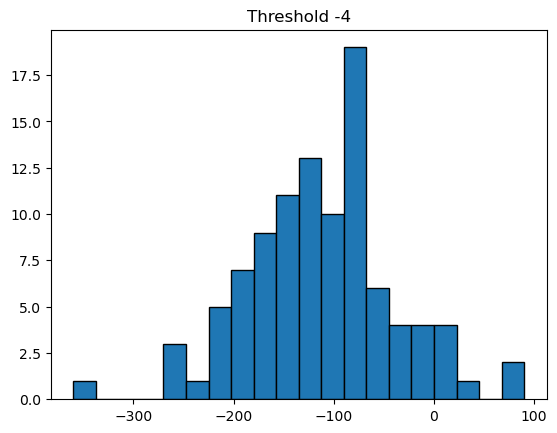


Threshold -2
Average: -133.8
Std Dev: 79.72176616207143
Prob Profit: 0.02


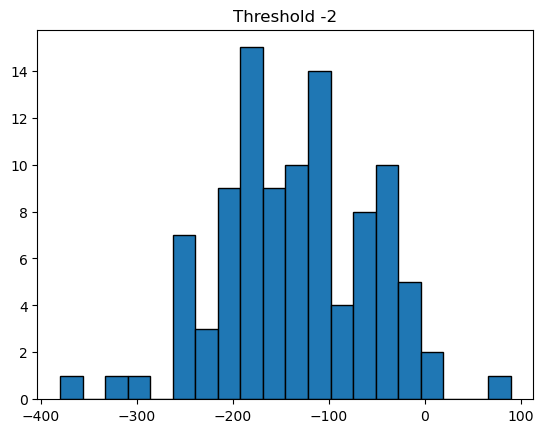


Threshold 0
Average: -167.9
Std Dev: 78.32362351168389
Prob Profit: 0.01


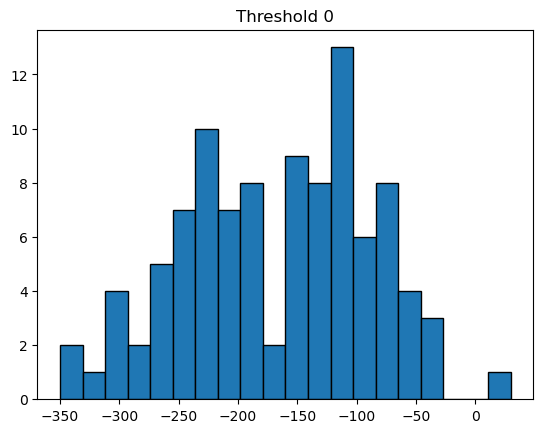


Threshold 2
Average: -200.8
Std Dev: 72.90651548387153
Prob Profit: 0.01


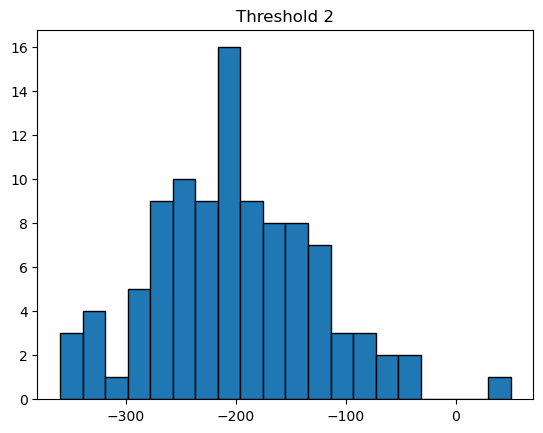


Threshold 4
Average: -224.4
Std Dev: 84.49047283569904
Prob Profit: 0.01


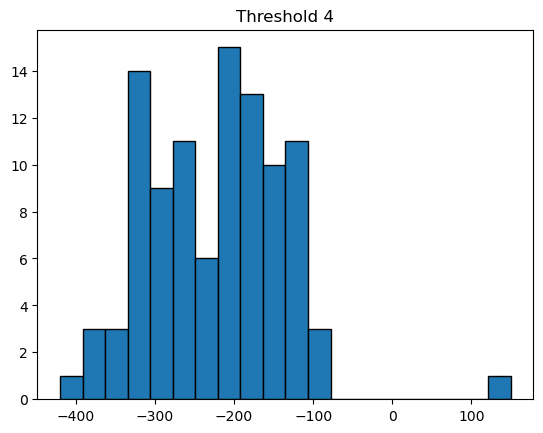

In [20]:
thresholds = [-4, -2, 0, 2, 4]

for t in thresholds:
    run_experiment(t)

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [21]:
class SmartBetPlayer(SimpleCountingPlayer):
    def make_decision(self, running_count, dealer_card):
        # Adjust bet based on count
        if running_count > 2:
            self.current_bet = 50
        elif running_count < -2:
            self.current_bet = 5
        else:
            self.current_bet = 10

        return super().make_decision(running_count, dealer_card)

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [ ]:
#Negative thresholds performed better because they allow more aggressive hitting, however it all resulted in negative average.

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [ ]:
#The best improvement came from adjusting bet size based on count
#This demonstrates that card counting alone is not enough and betting strategy matters.